# Segmentation of the cave edgings and paintings

Utilisation du dataset créé précédemment.

Etapes :
- Prétraitement



In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def loadImagebis(src):
    img=cv2.imread(src,1)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb,interpolation='nearest')
    plt.show()

## Prétraitement

Les images récoltées représentent des parois de grottes. Elles ne sont pas exploitables telles quelles, notamment dû au faible contraste entre la peinture/gravure et la roche, à cause du relief de la paroi qui introduit des zones d'ombre et déforme les objets d'intérêt, les éclairages sont très variables en fonction des photos...

Une phase de prétraitement est donc indispensable pour obtenir une segmentation la plus propre possible.

* correction d'exposition : pour que les éléments d'intérêt ressortent sur toutes les images du dataset, même les plus sombres. Méthode utilisée : retinex.
* passage dans différents espace de réprensation de la couleur (RGB, HSV et Lab).

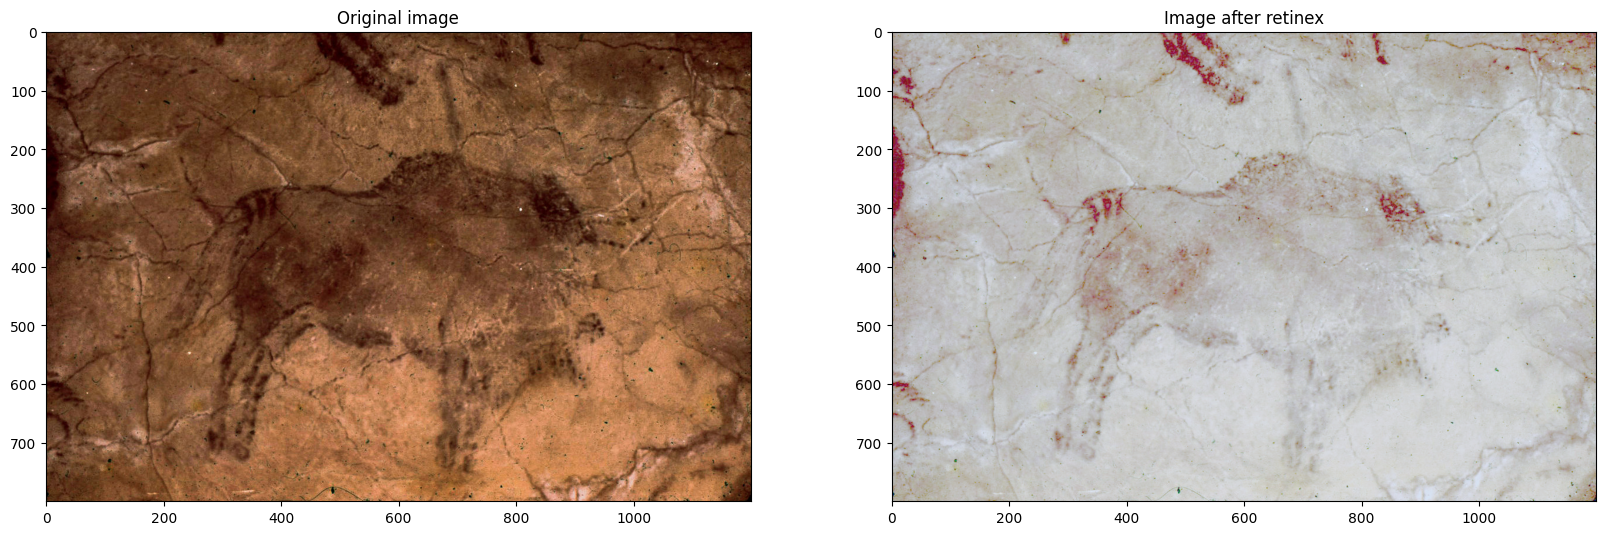

In [ ]:
# Retinex

def single_scale_retinex(img, sigma=1000):
    img = img.astype(np.float32) + 1.0
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    retinex = np.log(img) - np.log(blur)
    return retinex

# loadImagebis("dataset/altamira/Cueva_de_Altamira-19621007-001.jpg")

img = cv2.imread("dataset/altamira/Cueva_de_Altamira-19621007-001.jpg")
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
ret = single_scale_retinex(rgb)
ret = cv2.normalize(ret, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
ax1.set_title('Original image')
ax1.imshow(rgb, cmap='gray')
ax2.set_title('Image after retinex')
ax2.imshow(ret, cmap='gray')


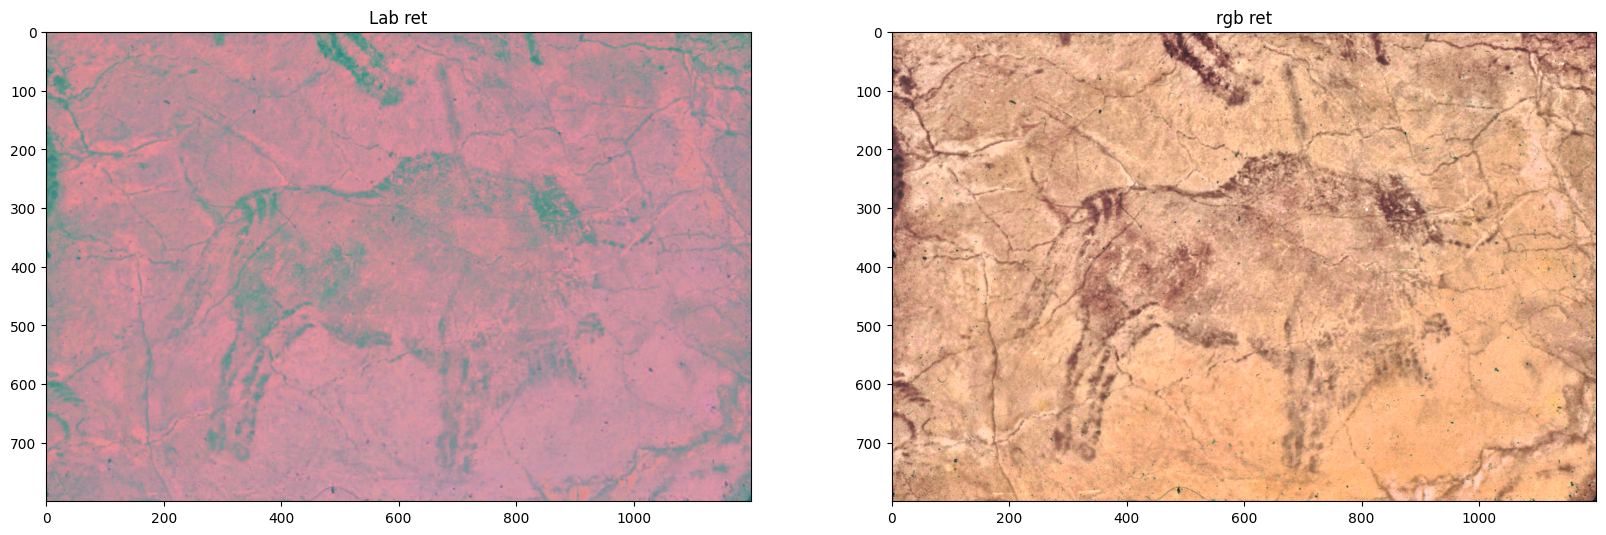

In [ ]:
def multi_scale_retinex(img, sigmas=(15, 80, 250)):
    ret = np.zeros_like(img, dtype=np.float32)
    for sigma in sigmas:
        ret += single_scale_retinex(img, sigma)
    ret /= len(sigmas)
    return ret


lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
L, a, b = cv2.split(lab)

# L_ret = single_scale_retinex(L, sigma=80)
L_ret = multi_scale_retinex(L, sigmas=(15, 80, 250))

L_ret = cv2.normalize(L_ret, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


lab_ret = cv2.merge([L_ret, a, b])
rgb_ret = cv2.cvtColor(lab_ret, cv2.COLOR_LAB2RGB)
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
ax1.set_title('Lab ret')
ax1.imshow(lab_ret, cmap='gray')
ax2.set_title('rgb ret')
ax2.imshow(rgb_ret, cmap='gray')

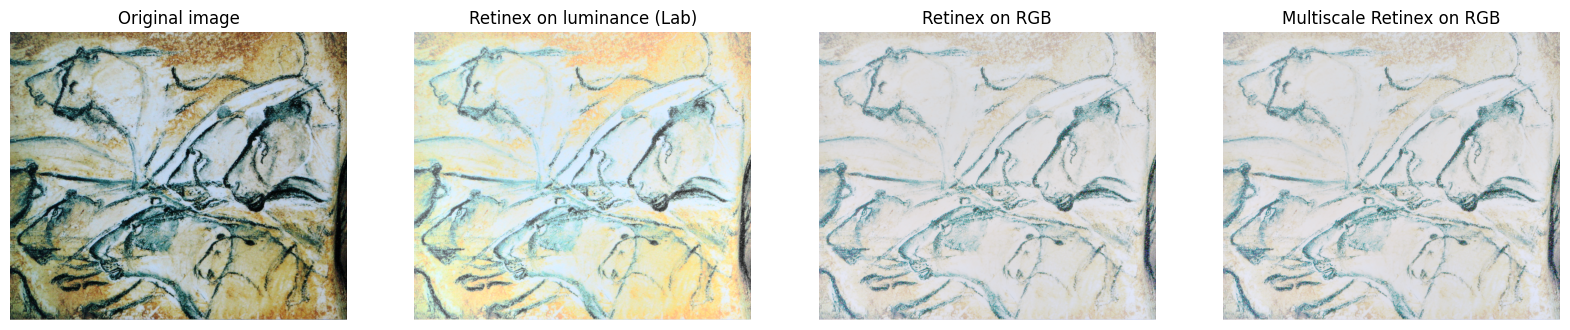

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def single_scale_retinex(img, sigma=60):
    img = img.astype(np.float32) + 1.0
    blur = cv2.GaussianBlur(img, (0, 0), sigma)
    retinex = np.log(img) - np.log(blur)
    return retinex

def multi_scale_retinex(img, sigmas=(15, 60, 120)):
    ret = np.zeros_like(img, dtype=np.float32)
    for sigma in sigmas:
        ret += single_scale_retinex(img, sigma)
    return ret / len(sigmas)

def plot_retinex(img):

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    r, g, bl = cv2.split(rgb)

    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    L, a, b = cv2.split(lab)

    # retinex
    L_ret = single_scale_retinex(L, sigma=200)
    L_ret = cv2.normalize(L_ret, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    rgb_ret = single_scale_retinex(rgb, sigma=200)
    rgb_ret = cv2.normalize(rgb_ret, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    rgb_ret_multi = multi_scale_retinex(rgb)
    rgb_ret_multi = cv2.normalize(rgb_ret, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    lab_ret = cv2.merge([L_ret, a, b])
    rgb_l_ret = cv2.cvtColor(lab_ret, cv2.COLOR_LAB2RGB)

    f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,10))
    ax1.set_title("Original image")
    ax1.imshow(rgb)
    ax1.axis("off")
    
    ax2.set_title("Retinex on luminance (Lab)")
    ax2.imshow(rgb_l_ret)
    ax2.axis("off")
    ax3.set_title("Retinex on RGB")
    ax3.imshow(rgb_ret)
    ax3.axis("off")
    ax4.set_title("Multiscale Retinex on RGB")
    ax4.imshow(rgb_ret_multi)
    ax4.axis("off")
    plt.show()
    
    return L, L_ret, a, b, r, g, bl
    
    

img1 = cv2.imread("dataset/altamira/Cueva_de_Altamira-19621007-001.jpg")
img2 = cv2.imread("dataset/altamira/Cueva_de_Altamira-19621007-002.jpg")
img3 = cv2.imread("dataset/altamira/Cueva_de_Altamira-19621007-003.jpg")
img4 = cv2.imread("dataset/altamira/Techo_de_Altamira_replica-Museo_Arqueologico_Nacional.jpg")
img5 = cv2.imread("dataset/mains/Gargas_-_Sanctuaire_des_Mains_Interieur_-_Main_noire_auriculaire_incomplet_pouce_replie_-_Main_rouge_majeur_et_auriculaire_incomplets_-_YR.jpg")
img6 = cv2.imread("dataset\chauvet\panel-of-the-lions-detail-chauvet-cave-6345.jpg")
    
# plot_retinex(img1)
# plot_retinex(img2)
# plot_retinex(img3)
# plot_retinex(img4)
L, Lret, a , b, r, g, bl = plot_retinex(img6)



## Segmentation par seuillage

Deux types de seuillage ont été réalisés

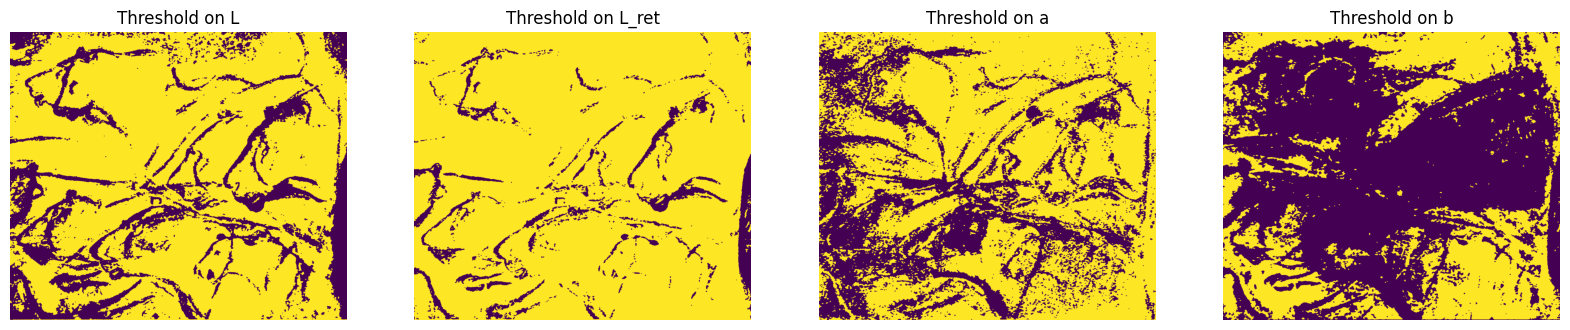

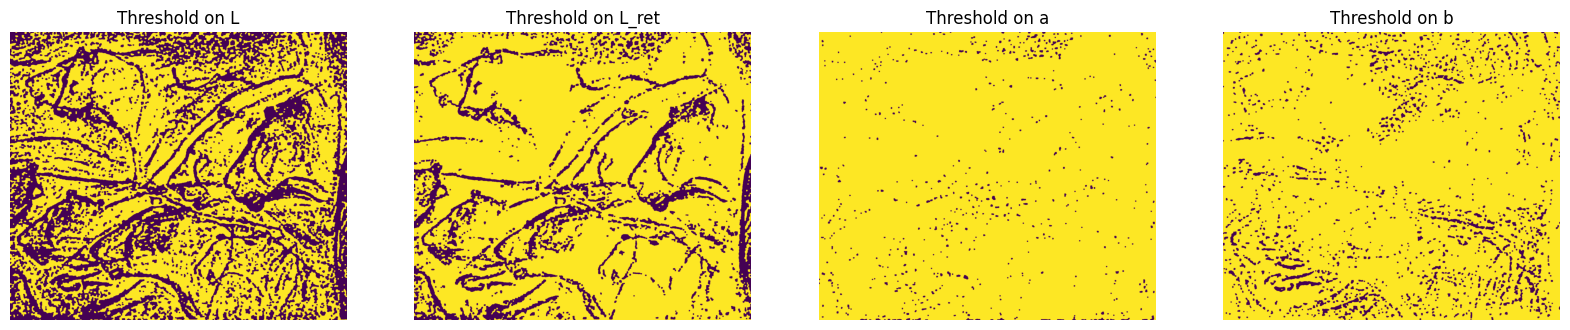

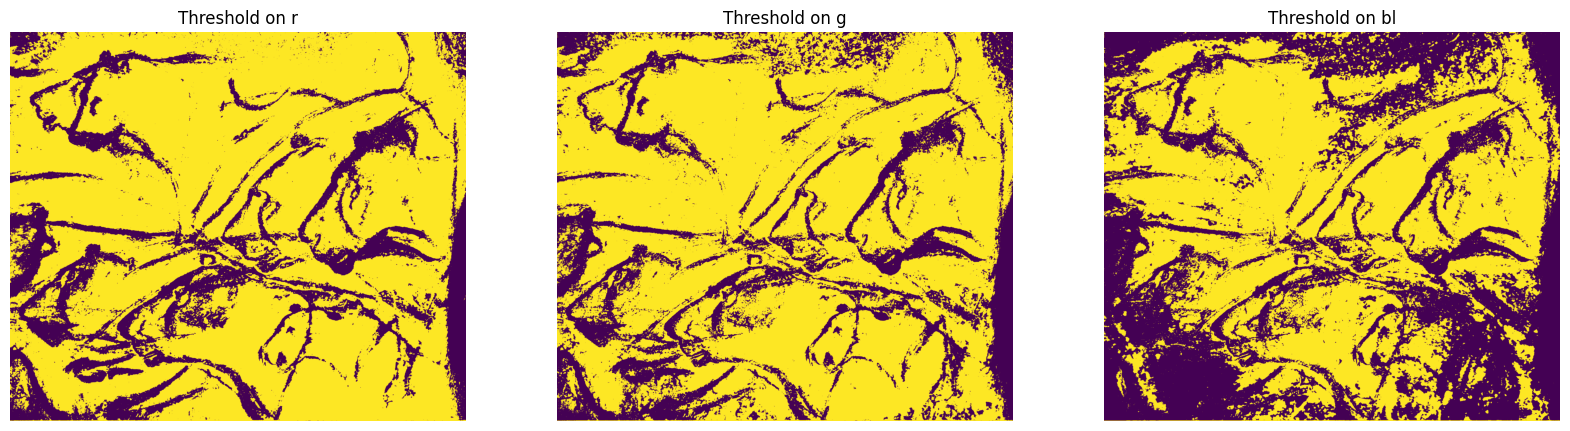

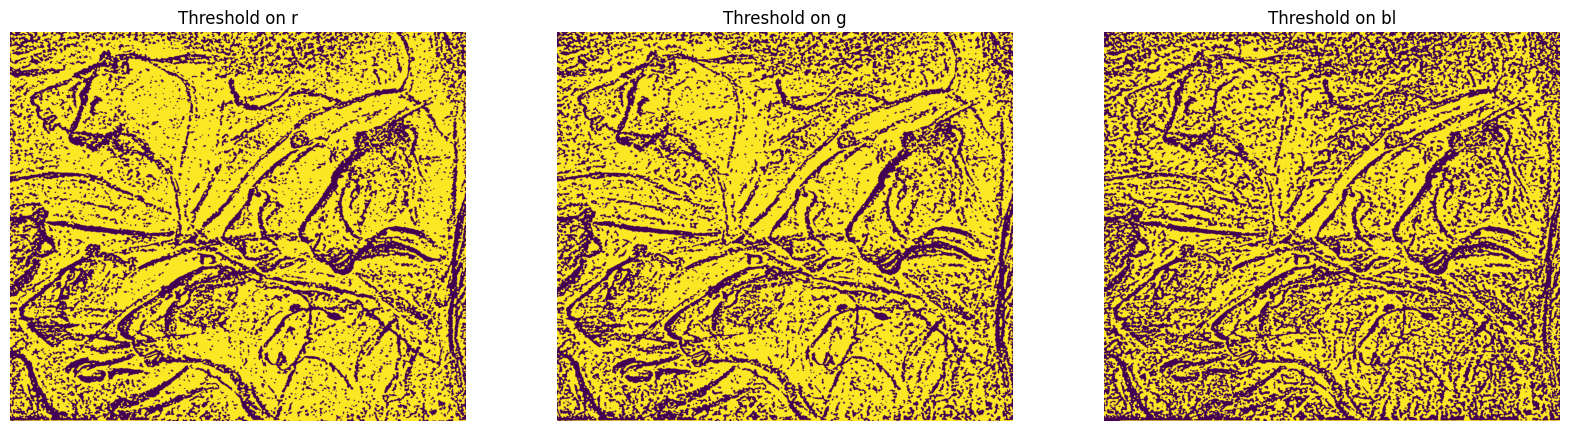

In [88]:
_, mask_L = cv2.threshold(L, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, mask_Lret = cv2.threshold(Lret, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, mask_a = cv2.threshold(a, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, mask_b = cv2.threshold(b, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
masks = [mask_L, mask_Lret, mask_a, mask_b]
masks = [
    cv2.morphologyEx(
        cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel),
        cv2.MORPH_CLOSE,
        kernel
    )
    for mask in masks
]
mask_L, mask_Lret, mask_a, mask_b = masks

f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,10))
ax1.set_title("Threshold on L")
ax1.imshow(mask_L)
ax1.axis("off")
ax2.set_title("Threshold on L_ret")
ax2.imshow(mask_Lret)
ax2.axis("off")
ax3.set_title("Threshold on a")
ax3.imshow(mask_a)
ax3.axis("off")
ax4.set_title("Threshold on b")
ax4.imshow(mask_b)
ax4.axis("off")
plt.show()

mask_L_ada = cv2.adaptiveThreshold(L, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)
mask_L_ret_ada = cv2.adaptiveThreshold(Lret, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)
mask_a_ada = cv2.adaptiveThreshold(a, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)
mask_b_ada = cv2.adaptiveThreshold(b, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (8, 8))
masks = [mask_L_ada, mask_L_ret_ada, mask_a_ada, mask_b_ada]
masks = [
    cv2.morphologyEx(
        cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel),
        cv2.MORPH_CLOSE,
        kernel
    )
    for mask in masks
]
mask_L_ada, mask_L_ret_ada, mask_a_ada, mask_b_ada = masks

f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20,10))
ax1.set_title("Threshold on L")
ax1.imshow(mask_L_ada)
ax1.axis("off")
ax2.set_title("Threshold on L_ret")
ax2.imshow(mask_L_ret_ada)
ax2.axis("off")
ax3.set_title("Threshold on a")
ax3.imshow(mask_a_ada)
ax3.axis("off")
ax4.set_title("Threshold on b")
ax4.imshow(mask_b_ada)
ax4.axis("off")
plt.show()

_, mask_r = cv2.threshold(r, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, mask_g = cv2.threshold(g, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, mask_bl = cv2.threshold(bl, 0, 255,
                        cv2.THRESH_BINARY + cv2.THRESH_OTSU)

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))
ax1.set_title("Threshold on r")
ax1.imshow(mask_r)
ax1.axis("off")
ax2.set_title("Threshold on g")
ax2.imshow(mask_g)
ax2.axis("off")
ax3.set_title("Threshold on bl")
ax3.imshow(mask_bl)
ax3.axis("off")
plt.show()

mask_r_ada = cv2.adaptiveThreshold(r, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)
mask_g_ada = cv2.adaptiveThreshold(g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)
mask_bl_ada = cv2.adaptiveThreshold(bl, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 51, 5)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
masks = [mask_r_ada, mask_g_ada, mask_bl_ada]
masks = [
    cv2.morphologyEx(
        cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel),
        cv2.MORPH_CLOSE,
        kernel
    )
    for mask in masks
]
mask_r_ada, mask_g_ada, mask_bl_ada = masks

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,10))
ax1.set_title("Threshold on r")
ax1.imshow(mask_r_ada)
ax1.axis("off")
ax2.set_title("Threshold on g")
ax2.imshow(mask_g_ada)
ax2.axis("off")
ax3.set_title("Threshold on bl")
ax3.imshow(mask_bl_ada)
ax3.axis("off")
plt.show()